### California Housing Price Regression — Student Version
------------------------------------------------------------

### Goals
In this notebook, you will practice how to:

1. Use four regression models to predict California housing prices:
   - K-Nearest Neighbors (KNN)
   - Linear Regression
   - Decision Tree
   - Neural Network
2. Compare their prediction performance on the same test set.
3. Use K-fold cross-validation to choose the neural network's:
   - hidden-layer structure
   - activation function

### How to use this notebook
Complete the places marked **TODO**.

Hints are provided in the comments. Try to complete each task before checking the instructor's demonstration.


In [11]:
# ============================================================
# Part 0. Load Python packages
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Dataset
from sklearn.datasets import fetch_california_housing

# Tools for splitting data and cross-validation
from sklearn.model_selection import train_test_split, KFold, GridSearchCV

# Regression models
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor

# Preprocessing and pipelines
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Evaluation metrics
from sklearn.metrics import mean_squared_error, r2_score


In [12]:
# ============================================================
# Part 1. Load and inspect the California Housing dataset
# ============================================================

# Load the dataset.
# Hint: use fetch_california_housing(as_frame=True)
housing = fetch_california_housing(as_frame=True)   # TODO

# X should contain the input features.
# Hint: use housing.data
X = housing.data         # TODO

# y should contain the target values.
# Hint: use housing.target
y = housing.target         # TODO

# After completing the three lines above, remove the comment signs
# below to inspect the dataset.

print("Feature names:")
print(list(X.columns))
print("\nNumber of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("\nFirst five samples:")
print(X.head())


Feature names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Number of samples: 20640
Number of features: 8

First five samples:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  


In [13]:
# ============================================================
# Part 2. Split the data into training and test sets
# ============================================================

# TODO:
# Split the data so that:
#   - 70% is used for training
#   - 30% is used for testing
#   - random_state = 42
#
# Hint:
# X_train, X_test, y_train, y_test = train_test_split(...)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


### Part 3A. Start with a Linear Regression Model

Complete a simple linear-regression workflow first.  
This gives us a pattern that we can later reuse for several models.


In [14]:
# ============================================================
# Part 3A. Fit and evaluate a linear regression model
# ============================================================

# TODO 1:
# Create a LinearRegression model.
linear_model = LinearRegression()

# TODO 2:
# Fit the model using X_train and y_train.
linear_model.fit(X_train, y_train)

# TODO 3:
# Use the fitted model to predict both the training set and test set.
y_train_pred = linear_model.predict(X_train)
y_test_pred = linear_model.predict(X_test)

# TODO 4:
# Calculate the training MSE and test MSE.
# Hint: mean_squared_error(actual_values, predicted_values)
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

# TODO 5:
# Calculate the test RMSE.
# Hint: RMSE is the square root of MSE.
test_rmse = np.sqrt(test_mse)

# TODO 6:
# Calculate the test R^2 score.
test_r2 = r2_score(y_test, y_test_pred)

# After completing the tasks above, display your results.
results = [{
    "Model": "Linear Regression",
    "Training MSE": train_mse,
    "Test MSE": test_mse,
    "Test RMSE": test_rmse,
    "Test R^2": test_r2
}]

df = pd.DataFrame(results)
print(df)


               Model  Training MSE  Test MSE  Test RMSE  Test R^2
0  Linear Regression      0.523358  0.530568   0.728401   0.59577


### Part 3B. Build More Regression Models

Now create KNN, a decision tree, and a neural network.

Think about this question while coding:

**Which models need feature scaling, and why?**


In [15]:
# ============================================================
# Part 3B. Define four regression models
# ============================================================

# ------------------------------------------------------------
# 1. K-Nearest Neighbors
# ------------------------------------------------------------
# KNN uses distances between samples, so feature scaling is important.
#
# TODO:
# Create a Pipeline containing:
#   1. StandardScaler()
#   2. KNeighborsRegressor with n_neighbors=5
#
# Hint:
# knn_model = Pipeline([
#     ("scaler", ...),
#     ("model", ...)
# ])

knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsRegressor(n_neighbors=5))
])


# ------------------------------------------------------------
# 2. Linear Regression
# ------------------------------------------------------------
# We already created this model in the previous section.
# Re-create it here so that all four models can be compared together.

linear_model = LinearRegression()   # TODO


# ------------------------------------------------------------
# 3. Decision Tree
# ------------------------------------------------------------
# A decision tree does not require StandardScaler.
#
# TODO:
# Create DecisionTreeRegressor with:
#   max_depth=10
#   random_state=42

tree_model = DecisionTreeRegressor(
    max_depth=10, 
    random_state=42)   # TODO


# ------------------------------------------------------------
# 4. Neural Network
# ------------------------------------------------------------
# MLPRegressor is scikit-learn's feed-forward neural-network regressor.
# Scaling is usually important for neural-network training.
#
# TODO:
# Create a Pipeline containing:
#   1. StandardScaler()
#   2. MLPRegressor with:
#        hidden_layer_sizes=(50,)
#        activation="relu"
#        max_iter=500
#        early_stopping=True
#        random_state=42

mlp_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPRegressor(
        hidden_layer_sizes=(50,),
        activation="relu",
        max_iter=500,
        early_stopping=True,
        random_state=42))
])


# ------------------------------------------------------------
# Store the four models
# ------------------------------------------------------------
# TODO:
# Put the four models into a dictionary named models.
#
# Suggested keys:
# "KNN (k=5)"
# "Linear Regression"
# "Decision Tree"
# "Neural Network"

models = {
    "KNN (k=5)": knn_model,
    "Linear Regression": linear_model,
    "Decision Tree": tree_model,
    "Neural Network": mlp_model
}


In [16]:
# ============================================================
# Part 4. Train and evaluate the four models
# ============================================================

# This list will store one dictionary of results for each model.
results = []

# TODO:
# Complete the loop below.
#
# For each model:
#   1. Fit the model using the training data.
#   2. Predict the training set.
#   3. Predict the test set.
#   4. Calculate training MSE.
#   5. Calculate test MSE.
#   6. Calculate test RMSE.
#   7. Calculate test R^2.
#   8. Append all results to the list.

for name, model in models.items():

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    test_rmse = np.sqrt(test_mse)
    test_r2 = r2_score(y_test, y_test_pred)

    results.append({
        "Model": name,
        "Training MSE": train_mse,
        "Test MSE": test_mse,
        "Test RMSE": test_rmse,
        "Test R^2": test_r2
    })

    pass


# TODO:
# Convert results to a pandas DataFrame.
results_df = pd.DataFrame(results)

# TODO:
# Sort the table from the smallest Test MSE to the largest.
results_df = results_df.sort_values(by="Test MSE")

print("\nPerformance of the four regression models:")
print(results_df.to_string(index=False))



Performance of the four regression models:
            Model  Training MSE  Test MSE  Test RMSE  Test R^2
   Neural Network      0.303298  0.312639   0.559141  0.761806
    Decision Tree      0.218761  0.415577   0.644653  0.683379
        KNN (k=5)      0.280003  0.429494   0.655358  0.672776
Linear Regression      0.523358  0.530568   0.728401  0.595770


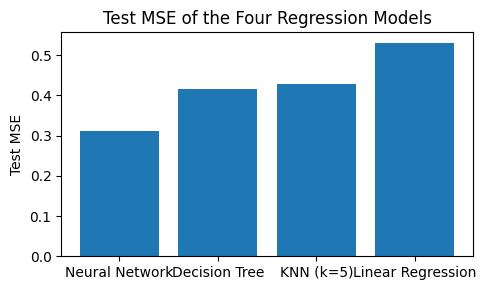

In [17]:
# ============================================================
# Part 5. Visualize the test MSE of the four models
# ============================================================

# TODO:
# Make a bar chart whose:
#   x-axis = model name
#   y-axis = test MSE
#
# Suggested commands:
plt.figure(figsize=(5, 3))
plt.bar(results_df["Model"], results_df["Test MSE"])
plt.ylabel("Test MSE")
plt.title("Test MSE of the Four Regression Models")
plt.tight_layout()
plt.show()


============================================================
### Part 6. Use K-Fold Cross-Validation to Tune the Neural Network
============================================================

We will choose two neural-network hyperparameters:

1. **hidden_layer_sizes** — the number of hidden layers and neurons per layer
2. **activation** — the activation function used by hidden neurons

We will compare:

- 1 hidden layer: `(50,)`
- 2 hidden layers: `(50, 50)`
- 3 hidden layers: `(50, 50, 50)`

and three activation functions:

- `"relu"`
- `"tanh"`
- `"logistic"`

### Important question

Why should we use only the **training set**, rather than the test set, to choose these hyperparameters?


In [18]:
# ============================================================
# Part 6. K-fold cross-validation for the neural network
# ============================================================

# ------------------------------------------------------------
# Step 1. Create the neural-network pipeline
# ------------------------------------------------------------
# TODO:
# Create a Pipeline containing StandardScaler and MLPRegressor.
#
# Use:
#   max_iter=500
#   early_stopping=True
#   random_state=42

mlp_for_search = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPRegressor(
        max_iter=500, 
        early_stopping=True, 
        random_state=42
    ))
])


# ------------------------------------------------------------
# Step 2. Define the hyperparameter grid
# ------------------------------------------------------------
# In a Pipeline, "model__" means that the parameter belongs to
# the pipeline step called "model".
#
# TODO:
# Test these hidden-layer structures:
#   (50,)
#   (50, 50)
#   (50, 50, 50)
#
# Also test:
#   "relu"
#   "tanh"
#   "logistic"

parameter_grid = {
    "model__hidden_layer_sizes": [
        (50,),
        (50, 50),
        (50, 50, 50)
    ],
    "model__activation": [
        "relu",
        "tanh",
        "logistic"
    ]
}


# ------------------------------------------------------------
# Step 3. Create 5-fold cross-validation
# ------------------------------------------------------------
# TODO:
# Create KFold using:
#   n_splits=5
#   shuffle=True
#   random_state=42

kfold = KFold(n_splits=5, shuffle=True, random_state=42)


# ------------------------------------------------------------
# Step 4. Create GridSearchCV
# ------------------------------------------------------------
# GridSearchCV will test every combination in parameter_grid.
#
# Use:
#   estimator=mlp_for_search
#   param_grid=parameter_grid
#   cv=kfold
#   scoring="neg_mean_squared_error"
#   n_jobs=-1
#   return_train_score=True

grid_search = GridSearchCV(
    estimator=mlp_for_search,
    param_grid=parameter_grid,
    cv=kfold,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    return_train_score=True
)


# ------------------------------------------------------------
# Step 5. Run the search
# ------------------------------------------------------------
# IMPORTANT: Fit GridSearchCV using the TRAINING SET only.
#
# TODO:
grid_search.fit(X_train, y_train)


# ------------------------------------------------------------
# Step 6. Inspect the best model
# ------------------------------------------------------------
# After GridSearchCV is fitted, uncomment these lines.

best_mlp = grid_search.best_estimator_
print("\nBest neural-network hyperparameters:")
print(grid_search.best_params_)

# GridSearchCV stores MSE as a negative value because it tries
# to MAXIMIZE a score. Convert it back to positive MSE.

best_cv_mse = -grid_search.best_score_
print(f"Best mean validation MSE from 5-fold CV: {best_cv_mse:.4f}")



Best neural-network hyperparameters:
{'model__activation': 'tanh', 'model__hidden_layer_sizes': (50, 50, 50)}
Best mean validation MSE from 5-fold CV: 0.2926


In [19]:
# ============================================================
# Part 7. Inspect all K-fold neural-network results
# ============================================================

# After finishing Part 6, uncomment the first line.
cv_results = pd.DataFrame(grid_search.cv_results_)

# TODO:
# Select the following columns:
#   param_model__hidden_layer_sizes
#   param_model__activation
#   mean_test_score
#   std_test_score
#   rank_test_score

cv_summary = cv_results[[
    "param_model__hidden_layer_sizes",
    "param_model__activation",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].copy()

# TODO:
# Convert negative mean_test_score to positive validation MSE.
#
cv_summary["Mean Validation MSE"] = -cv_summary["mean_test_score"]

# The following code can be used after completing the two TODOs above.

cv_summary = cv_summary.drop(columns="mean_test_score")

cv_summary = cv_summary.rename(columns={
    "param_model__hidden_layer_sizes": "Hidden Layers",
    "param_model__activation": "Activation",
    "std_test_score": "Std. of CV Score",
    "rank_test_score": "Rank"
})

cv_summary = cv_summary.sort_values("Rank")

print("\nAll neural-network cross-validation results:")
print(cv_summary.to_string(index=False))



All neural-network cross-validation results:
Hidden Layers Activation  Std. of CV Score  Rank  Mean Validation MSE
 (50, 50, 50)       tanh          0.025823     1             0.292647
 (50, 50, 50)       relu          0.008257     2             0.297645
     (50, 50)       relu          0.008070     3             0.303870
     (50, 50)       tanh          0.010103     4             0.312427
        (50,)       tanh          0.011624     5             0.326439
        (50,)       relu          0.037500     6             0.337650
        (50,)   logistic          0.009806     7             0.344425
     (50, 50)   logistic          0.012721     8             0.346242
 (50, 50, 50)   logistic          0.013641     9             0.349102


In [21]:
# ============================================================
# Part 8. Final evaluation of the selected neural network
# ============================================================

# Only after selecting the neural network by cross-validation
# should we evaluate it on the untouched test set.

# TODO 1:
# Use best_mlp to predict X_test.
y_test_pred_best_mlp = best_mlp.predict(X_test)

# TODO 2:
# Calculate:
#   - Test MSE
#   - Test RMSE
#   - Test R^2
#
best_test_mse = mean_squared_error(y_test, y_test_pred_best_mlp)
best_test_rmse = np.sqrt(best_test_mse)
best_test_r2 = r2_score(y_test, y_test_pred_best_mlp)

# After completing the calculations, uncomment:

print("\nFinal performance of the K-fold-selected neural network:")
print(f"Test MSE : {best_test_mse:.4f}")
print(f"Test RMSE: {best_test_rmse:.4f}")
print(f"Test R^2 : {best_test_r2:.4f}")



Final performance of the K-fold-selected neural network:
Test MSE : 0.2664
Test RMSE: 0.5161
Test R^2 : 0.7971
